## Problem 4.3

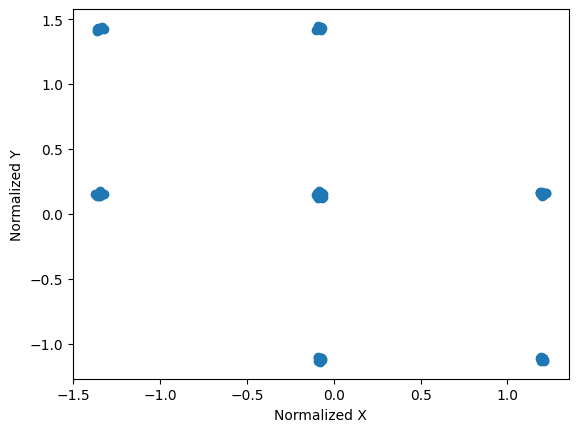

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# ========================= Loading dataset of 2D points of various color ======================================
with open('./SMAI-Dataset-problem-4.3/colors.pkl', 'rb') as f:
    data = np.load(f, allow_pickle=True)
    
#print(data)
#print(data.shape)

# =================================== Pre processing the data ==================================================

# Using In-built function
# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(data)
# plt.scatter(scaled_data[:,0], scaled_data[:,1])
# plt.show()
# X= scaled_data

#print(np.mean(data, axis=0))
data[:,0]-= np.mean(data, axis=0)[0] 
data[:,1]-= np.mean(data, axis=0)[1]

data[:,0] /= data.shape[0]
data[:,1] /= data.shape[0]

X = data

# ====================================== Plot the data points ====================================================
plt.scatter(data[:,0], data[:,1])
plt.xlabel("Normalized X")
plt.ylabel("Normalized Y")
plt.show()

# =================================== Create and fit the GMM model ===============================================
# Finding the likely color components which generate the dataset.

gmm = GaussianMixture(n_components=7)
gmm.fit(X) 

labels = gmm.predict(X)

means = gmm.means_
covariances = gmm.covariances_

#print(means)
#print(covariances)


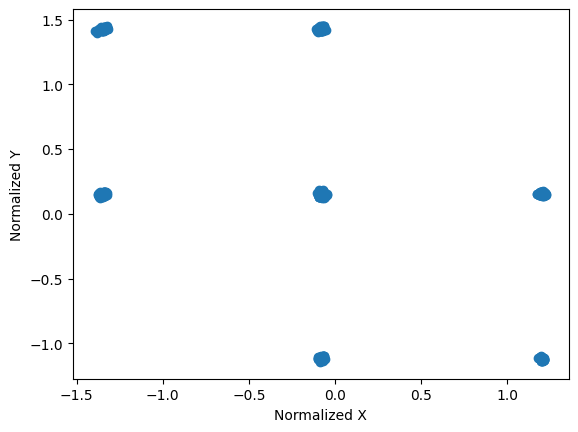

In [2]:
# Some part were ChatGPT generated. 
def generate_sample_dataset(n, means, covariances, samples_per_component):
    """
    Input:
        n: number of components (an integer).
        means: an numpy array of shape (n, 2)).
        covariances: a numpy array of shape n, 2, 2))

    Output: 
        dataset with the n likely components described by the above components.
    """
    
    dataset = []
    for i in range(0, n):
        component_samples = np.random.multivariate_normal(means[i], covariances[i], samples_per_component)
        dataset.extend(component_samples)
    return np.array(dataset)

n=7
samples_per_component = 100
generated_dataset = generate_sample_dataset(n, means, covariances, samples_per_component)
# print(generated_dataset.shape)  
plt.scatter(generated_dataset[:, 0], generated_dataset[:, 1])
plt.xlabel("Normalized X")
plt.ylabel("Normalized Y")
plt.show()


### Observation 
This approach helps us to estimate a given dataset according to Gaussian Mixture Model (GMM). 
We can find means and variances by choosing a suitable value of the number of components. 
Then we can use the values to obtain many similar datasets using it. 